   transaction_id user_id  age  gender  daily_screen_time_hours  social_media_hours  gaming_hours  work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  weekend_screen_time stress_level academic_work_impact addiction_level addicted_label
0        TXN00001  U00001   21    Male                     3.23                2.01          0.89              4.55         7.55                    248                154                 3.95       Medium                  Yes             NaN   Not Addicted
1        TXN00002  U00002   24   Other                     5.09                3.81          2.24              4.44         7.66                    127                 71                 6.71       Medium                  Yes             NaN   Not Addicted
2        TXN00003  U00003   31   Other                     6.06                1.36          3.83              2.35         4.92                     44                106                 8.68         High                   No    

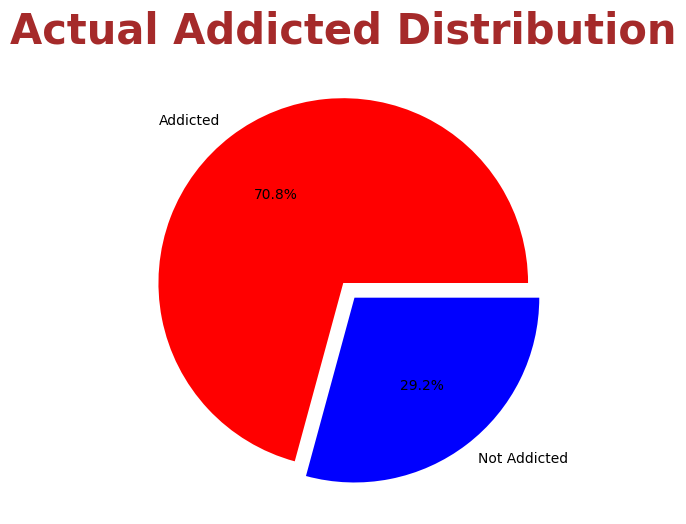

   transaction_id user_id  age  gender  daily_screen_time_hours  social_media_hours  gaming_hours  work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  weekend_screen_time  stress_level  academic_work_impact addiction_level addicted_label
0        TXN00001  U00001   21       1                     3.23                2.01          0.89              4.55         7.55                    248                154                 3.95             2                     1             NaN   Not Addicted
1        TXN00002  U00002   24       2                     5.09                3.81          2.24              4.44         7.66                    127                 71                 6.71             2                     1             NaN   Not Addicted
2        TXN00003  U00003   31       2                     6.06                1.36          3.83              2.35         4.92                     44                106                 8.68             0                  

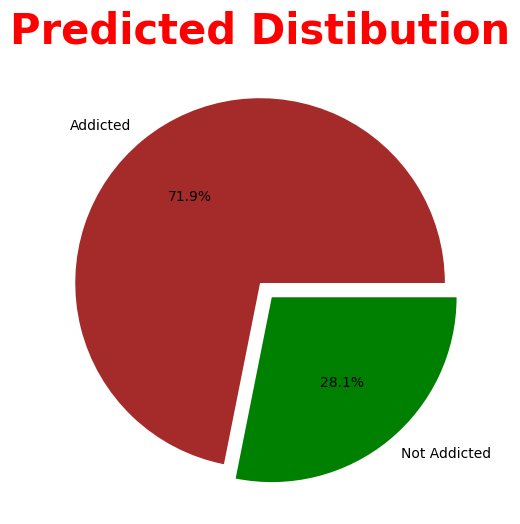

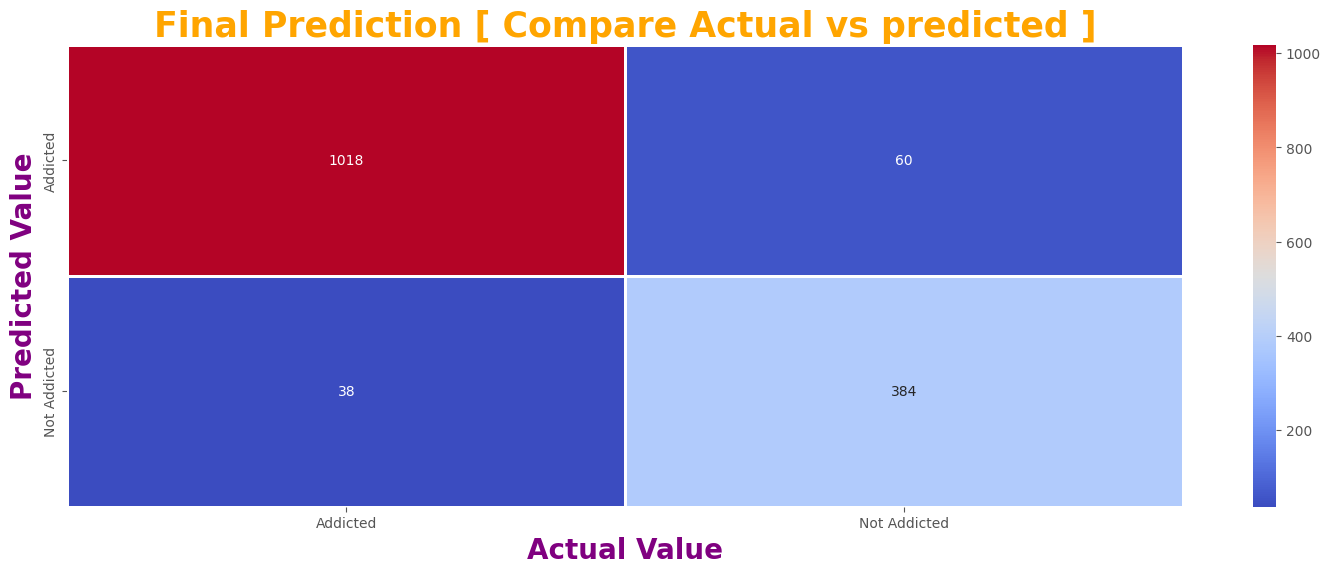

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
plt.style.use('ggplot')

pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.width',None)
pd.set_option('display.expand_frame_repr',False)

JP=pd.read_csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
print(JP.head(20))

print(JP.isna().sum())
# JP=JP[JP.duplicated()]
# print(JP)

plt.figure(figsize=(22,6))
plt.pie(JP['addicted_label'].value_counts(),labels=JP['addicted_label'].value_counts().index,autopct='%1.1f%%',colors=['red','blue'],explode=[0,0.1])
plt.title("Actual Addicted Distribution",fontsize=30,fontweight='bold',color='brown')
plt.show()

from sklearn.preprocessing  import LabelEncoder

JP['stress_level']=LabelEncoder().fit_transform(JP['stress_level'])
JP['academic_work_impact']=LabelEncoder().fit_transform(JP['academic_work_impact'])
JP['gender']=LabelEncoder().fit_transform(JP['gender'])

print(JP.head(20))

x=JP[['daily_screen_time_hours','social_media_hours','gaming_hours','weekend_screen_time','stress_level','academic_work_impact',
      'work_study_hours','sleep_hours','notifications_per_day','app_opens_per_day']]
y=JP['addicted_label']


from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier(max_depth=5)

score=cross_val_score(model,x,y,cv=5,scoring='accuracy')

print("\n")
print("CVS == ",score)
print("Average CVS ==",score.mean())

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=29)


from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier(max_depth=5,random_state=27)

model.fit(x_train,y_train)
Y_Pred=model.predict(x_test)


# from sklearn.ensemble  import RandomForestClassifier

# model=RandomForestClassifier(n_estimators=100,random_state=97)

# model.fit(x_train,y_train)
# Y_Pred=model.predict(x_test)


# from sklearn.linear_model import LogisticRegression

# model=LogisticRegression(max_iter=1000)

# model.fit(x_train,y_train)
# Y_Pred=model.predict(x_test)



Train=model.score(x_train,y_train)
Test=model.score(x_test,y_test)

print("\n")
print("Train Score",Train)
print("Test Score",Test)

from sklearn.metrics import accuracy_score , confusion_matrix , classification_report 

print("\n")
print("Accuracy Score",accuracy_score(y_test,Y_Pred) * 100 , "%")

print("\n")
CM=confusion_matrix(y_test,Y_Pred)
print("Confusion Matrix")
print(CM)

print("\n")
print("Classification Report")
print(classification_report(y_test,Y_Pred))


plt.figure(figsize=(22,6))
plt.pie(y_test.value_counts(),labels=y_test.value_counts().index,autopct='%1.1f%%',colors=['brown','green'],explode=[0,0.1])
plt.title("Predicted Distibution",fontsize=30,fontweight='bold',color='red')
plt.show()


plt.figure(figsize=(18,6))
sns.heatmap(CM,annot=True,fmt='d',cmap='coolwarm',xticklabels=['Addicted','Not Addicted'],yticklabels=['Addicted','Not Addicted'],linewidth=1)
plt.title("Final Prediction [ Compare Actual vs predicted ]",fontsize=25,fontweight='bold',color='orange')
plt.xlabel("Actual Value",fontsize=20,fontweight='bold',color='purple')
plt.ylabel("Predicted Value",fontsize=20,fontweight='bold',color='purple')
plt.show()